In [1]:
import pandas as pd
import numpy as np 
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
import os
import spatialdata as spd

from matplotlib import rcParams

rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


# Data

## Locations

In [2]:
# Selected level of annotation for training the model.
level = 1
levels = ["cell_type_lvl1", "cell_type_lvl2", "cell_type_lvl3"]

level_short = {
    "cell_type_lvl1": "lvl1",
    "cell_type_lvl2": "lvl2",
    "cell_type_lvl3": "lvl3",
}

In [3]:

current_level = levels[level]
lvl_name_short =level_short[current_level]

In [ ]:
# Project folder
# proj_folder   = Path("/Users/janzules/Roselab/Spatial/CAR_T/")
proj_folder   = Path("/coh_labs/yunroseli/Jona/CAR-T/")
c2l_folder     = proj_folder / "results/cell2location/"

# Files for training and mapping
input_folder   = c2l_folder / "C2L_inputs"

figures_folder = proj_folder / "figures/cell2location/training"


# ref_loc        = input_folder / "ref_adata_c2l_model.h5ad"
spatial_loc   = input_folder / "spatial_sdata_c2l_model.h5ad"

# Output location - Not sure what these are for
ref_run_name   = c2l_folder / f"reference_signatures_{lvl_name_short}"
run_name       = c2l_folder / f"c2l_{lvl_name_short}"

# After training
trained_sc_data_file = input_folder / f"sc_with_signatures_{lvl_name_short}.h5ad"
predicted_cells_file = input_folder / f"predicted_cells_{lvl_name_short}.h5ad"

In [5]:
spatial_loc

PosixPath('/coh_labs/yunroseli/Jona/CAR-T/results/cell2location/C2L_inputs/spatial_sdata_c2l_model.h5ad')

In [11]:
# Load data
adata_vis = sc.read_h5ad(predicted_cells_file)
# adata_ref = sc.read_h5ad(trained_sc_data_file)

In [8]:
# export estimated expression in each cluster
if 'means_per_cluster_mu_fg' in adata_ref.varm.keys():
    inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
else:
    inf_aver = adata_ref.var[[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
inf_aver.columns = adata_ref.uns['mod']['factor_names']
inf_aver.iloc[0:5, 0:5]

KeyError: "None of [Index(['means_per_cluster_mu_fg_B', 'means_per_cluster_mu_fg_CD4_T',\n       'means_per_cluster_mu_fg_CD8_T', 'means_per_cluster_mu_fg_Cancer_cell',\n       'means_per_cluster_mu_fg_Classical_Mono',\n       'means_per_cluster_mu_fg_Endothelial',\n       'means_per_cluster_mu_fg_Erythrocyte',\n       'means_per_cluster_mu_fg_Fibroblast',\n       'means_per_cluster_mu_fg_Intermediate_Mac',\n       'means_per_cluster_mu_fg_M1_like_Mac',\n       'means_per_cluster_mu_fg_M2_like_Mac',\n       'means_per_cluster_mu_fg_N1_like_Neu',\n       'means_per_cluster_mu_fg_N2_like_Neu', 'means_per_cluster_mu_fg_NK',\n       'means_per_cluster_mu_fg_NKT',\n       'means_per_cluster_mu_fg_Nonclassical_Mono',\n       'means_per_cluster_mu_fg_Treg', 'means_per_cluster_mu_fg_cDC',\n       'means_per_cluster_mu_fg_pDC'],\n      dtype='object')] are in the [columns]"

# Visualizing

In [13]:
inf_aver

,B,CD4_T,CD8_T,Cancer_cell,Classical_Mono,Endothelial,Erythrocyte,Fibroblast,Intermediate_Mac,M1_like_Mac,M2_like_Mac,N1_like_Neu,N2_like_Neu,NK,NKT,Nonclassical_Mono,Treg,cDC,pDC
gene_id,,,,,,,,,,,,,,,,,,,
ENSMUSG00000051951,0.029603,0.017300,0.011325,0.010806,0.000611,0.019447,0.015372,0.484880,0.003209,0.001495,0.003804,0.000964,0.000840,0.003492,0.011877,0.002018,0.017956,0.007234,0.008815
ENSMUSG00000025902,0.022129,0.012658,0.001919,0.000348,0.000076,1.098562,0.011708,0.003950,0.000210,0.000116,0.000063,0.000577,0.000711,0.001130,0.011553,0.000340,0.015580,0.000784,0.004855
ENSMUSG00000025903,0.168787,0.388103,0.279053,0.086015,0.251908,0.354816,0.015562,0.292435,0.424520,0.305408,0.379528,0.041306,0.017978,0.267334,0.174841,0.303539,0.378487,0.247356,0.218247
ENSMUSG00000033813,0.215083,0.738445,0.530219,0.589549,0.514592,0.491836,0.114360,0.882650,0.876479,0.695321,0.857719,0.063812,0.032221,0.725838,0.434004,0.508723,0.642500,0.711397,0.805755
ENSMUSG00000002459,0.574192,0.309674,0.020432,0.005635,0.000237,0.020910,0.394635,0.122277,0.001171,0.000536,0.001147,0.000843,0.001066,0.001826,0.303217,0.000462,0.435236,0.002553,0.064019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000056673,0.272948,0.342930,0.236953,0.000454,0.109732,0.316673,0.011732,0.372812,0.189481,0.127825,0.184948,0.014103,0.018138,0.315277,0.188672,0.143167,0.263494,0.242690,0.202944
ENSMUSG00000069049,0.671355,0.934111,0.758261,0.007218,0.709833,0.618943,0.013150,0.784230,0.933320,0.821931,0.862884,0.227144,0.250240,0.992546,0.650329,0.757008,0.817606,0.847205,0.838960
ENSMUSG00000068457,0.620220,1.980321,1.536534,0.000975,0.698157,1.713936,0.014264,1.502089,1.168766,0.914060,1.552958,0.188732,0.159074,1.570144,1.979918,0.724029,1.750087,1.387257,1.252977


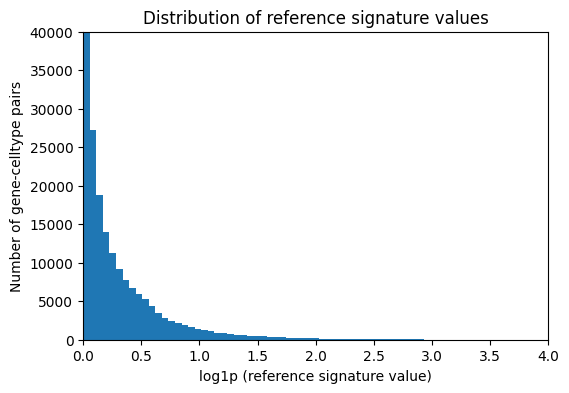

In [ ]:
vals = inf_aver.to_numpy().ravel()
vals = vals[np.isfinite(vals)]

plt.figure(figsize=(6,4))
plt.hist(np.log1p(vals), bins=100)
plt.hist(vals, bins=1000)
plt.xlabel("log1p (reference signature value)")
plt.xlim(0, 4)
plt.ylim(0, 40000)
plt.ylabel("Number of gene-celltype pairs")
plt.title("Distribution of reference signature values")
plt.show()

In [23]:
summary = inf_aver.describe().T[['mean', '50%', 'std', 'max']]
summary = summary.sort_values('50%', ascending=False)
print(summary.head(20))

                       mean       50%       std         max
Fibroblast         0.818180  0.289851  2.967169  159.187103
CD4_T              0.553285  0.214974  1.402522   82.434563
Endothelial        0.548773  0.205420  1.297559   51.961388
Treg               0.465147  0.184921  1.098368   52.679916
M2_like_Mac        0.702772  0.182680  3.073894  181.359497
NK                 0.565071  0.182121  1.898665  143.281052
Intermediate_Mac   0.627751  0.169180  2.644106  193.550369
pDC                0.486136  0.159243  1.312326   49.779030
NKT                0.372261  0.139914  0.908708   53.206333
CD8_T              0.424621  0.131987  1.335941   91.604454
M1_like_Mac        0.531188  0.121801  2.093453  127.932854
cDC                0.556882  0.121406  3.064986  280.926392
B                  0.290486  0.117635  0.584557   18.250605
Nonclassical_Mono  0.408976  0.097334  1.481896   98.619713
Classical_Mono     0.424649  0.084555  1.591493   96.105431
Cancer_cell        0.206664  0.045654  1

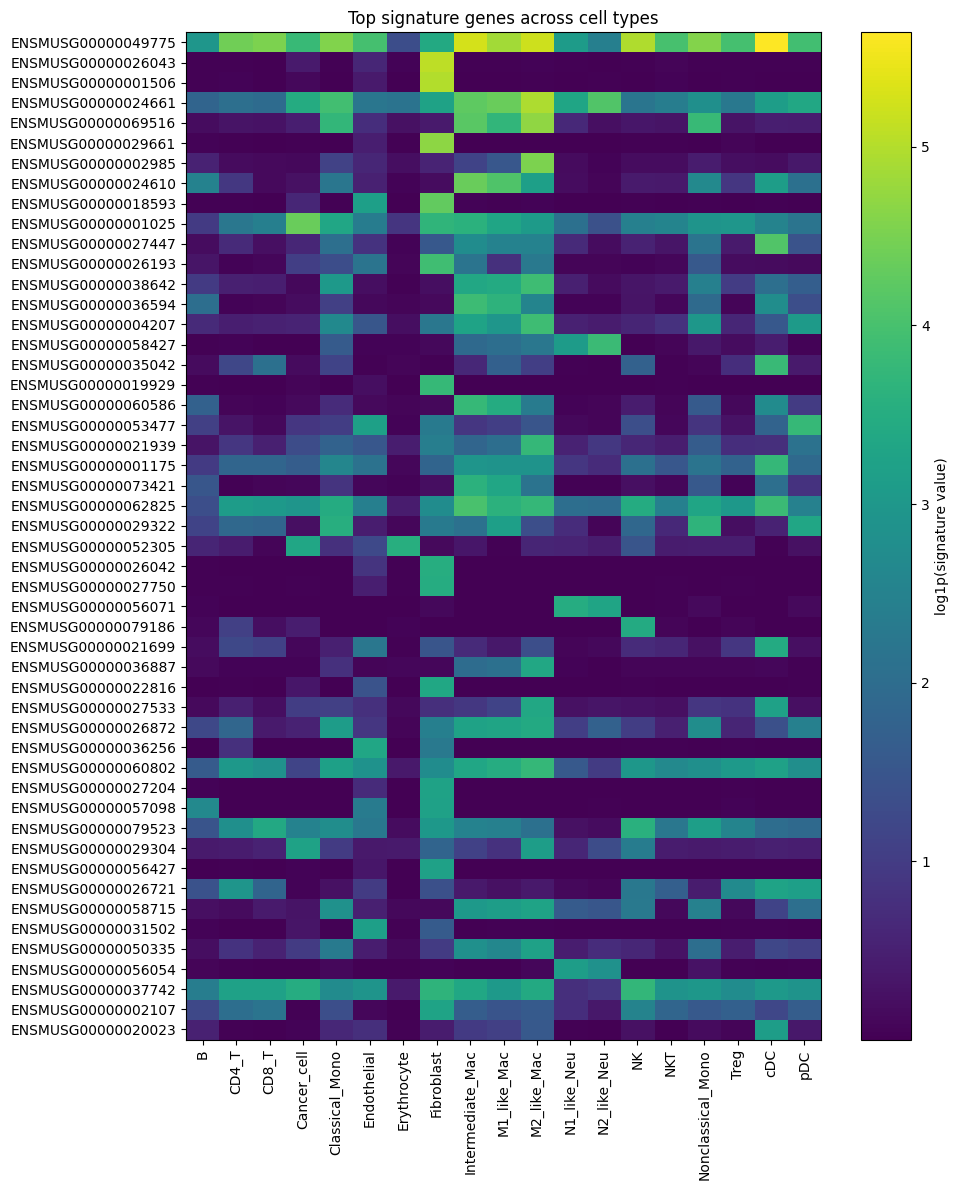

In [24]:
# choose genes with strongest specificity across cell types
specificity_score = inf_aver.max(axis=1) - inf_aver.median(axis=1)
top_genes = specificity_score.sort_values(ascending=False).head(50).index

plot_df = np.log1p(inf_aver.loc[top_genes])

plt.figure(figsize=(10, 12))
plt.imshow(plot_df.values, aspect='auto')
plt.colorbar(label='log1p(signature value)')
plt.xticks(range(plot_df.shape[1]), plot_df.columns, rotation=90)
plt.yticks(range(plot_df.shape[0]), plot_df.index)
plt.title("Top signature genes across cell types")
plt.tight_layout()
plt.show()

In [25]:
plot_df

,B,CD4_T,CD8_T,Cancer_cell,Classical_Mono,Endothelial,Erythrocyte,Fibroblast,Intermediate_Mac,M1_like_Mac,M2_like_Mac,N1_like_Neu,N2_like_Neu,NK,NKT,Nonclassical_Mono,Treg,cDC,pDC
gene_id,,,,,,,,,,,,,,,,,,,
ENSMUSG00000049775,2.957542,4.424063,4.528337,3.809576,4.575797,3.969563,1.323414,3.429777,5.270691,4.859292,5.205980,3.092478,2.442769,4.971763,3.992798,4.601360,3.983039,5.641646,3.927484
ENSMUSG00000026043,0.035294,0.031674,0.022690,0.415598,0.027131,0.617452,0.059231,5.076343,0.033565,0.043446,0.050746,0.024092,0.020583,0.025807,0.068155,0.024728,0.026152,0.041601,0.035138
ENSMUSG00000001506,0.036840,0.054586,0.009700,0.124227,0.018502,0.416116,0.021677,4.993003,0.016141,0.022168,0.029983,0.008983,0.025742,0.022049,0.047655,0.020965,0.031717,0.017611,0.016357
ENSMUSG00000024661,1.816440,2.071944,1.972614,3.461625,3.923088,2.224028,2.147051,3.248355,4.247598,4.363152,4.953629,3.321134,4.118189,2.204056,2.389696,2.809375,2.259022,3.140233,3.378696
ENSMUSG00000069516,0.192980,0.288524,0.273305,0.484408,3.735040,0.730991,0.253497,0.413334,4.193382,3.724537,4.711313,0.642527,0.240442,0.336169,0.297564,3.805590,0.288077,0.478513,0.458497
ENSMUSG00000029661,0.051106,0.023298,0.014072,0.024686,0.011938,0.484487,0.041333,4.689281,0.009604,0.017260,0.021987,0.004015,0.006920,0.030022,0.026640,0.014019,0.067458,0.010048,0.021068
ENSMUSG00000002985,0.547550,0.167364,0.140703,0.116549,1.121652,0.603329,0.217715,0.567178,1.130589,1.530412,4.539226,0.172848,0.050647,0.185158,0.196365,0.428062,0.202091,0.197384,0.360771
ENSMUSG00000024610,2.502831,0.912721,0.133817,0.259265,2.224840,0.521371,0.049006,0.198827,4.342793,4.081530,3.181451,0.189841,0.080089,0.399160,0.384811,2.646588,0.894551,3.138149,2.079363
ENSMUSG00000018593,0.023711,0.040410,0.022369,0.615694,0.035271,3.194150,0.018614,4.285789,0.045744,0.039117,0.056438,0.017344,0.016079,0.022947,0.014992,0.030656,0.022409,0.029324,0.016801


# Signatures

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def clean_cols(df):
    df = df.copy()
    df.columns = [c.split("w_sf_")[-1] for c in df.columns]
    return df

w_mean = clean_cols(adata_vis.obsm["means_cell_abundance_w_sf"])
w05    = clean_cols(adata_vis.obsm["q05_cell_abundance_w_sf"])
w95    = clean_cols(adata_vis.obsm["q95_cell_abundance_w_sf"])

# total inferred abundance per cell
total = w_mean.sum(axis=1)

# argmax label + top score (mean)
label = w_mean.idxmax(axis=1)
score = w_mean.max(axis=1)

# dominance / ambiguity: top1 - top2
vals = np.sort(w_mean.to_numpy(), axis=1)
margin = vals[:, -1] - vals[:, -2]

# conservative confidence: q05 of the winning label
idx = pd.Index(w05.columns).get_indexer(label.to_numpy())
rows = np.arange(adata_vis.n_obs)
q05_winner = w05.to_numpy()[rows, idx]

# store in obs for later plotting
adata_vis.obs["c2l_total_mean"] = total.to_numpy()
adata_vis.obs["c2l_label_mean"] = label.astype(str).to_numpy()
adata_vis.obs["c2l_score_mean"] = score.to_numpy()
adata_vis.obs["c2l_margin_mean"] = margin
adata_vis.obs["c2l_q05_winner"] = q05_winner

adata_vis.obs[["c2l_total_mean","c2l_score_mean","c2l_margin_mean","c2l_q05_winner"]].describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99])


,c2l_total_mean,c2l_score_mean,c2l_margin_mean,c2l_q05_winner
count,425859.000000,425859.000000,425859.000000,425859.000000
mean,1.507520,0.080002,0.000167,0.067553
std,0.001548,0.000190,0.000148,0.000589
min,1.500534,0.079363,0.000000,0.064352
1%,1.503934,0.079622,0.000002,0.066142
5%,1.504969,0.079718,0.000010,0.066569
10%,1.505538,0.079772,0.000020,0.066795
25%,1.506475,0.079868,0.000054,0.067160
50%,1.507520,0.079986,0.000126,0.067561
75%,1.508565,0.080118,0.000238,0.067954


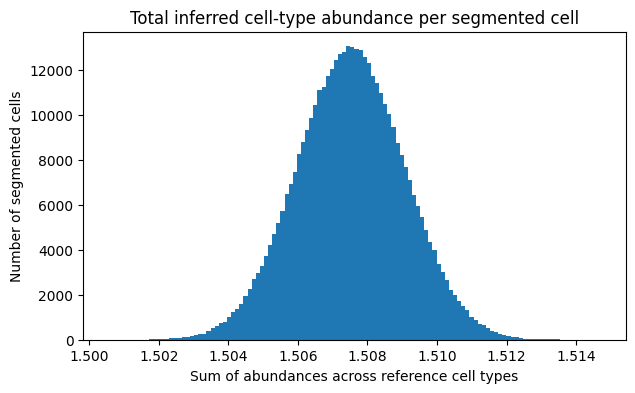

In [13]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(adata_vis.obs["c2l_total_mean"], bins=120)
ax.set_title("Total inferred cell-type abundance per segmented cell")
ax.set_xlabel("Sum of abundances across reference cell types")
ax.set_ylabel("Number of segmented cells")
plt.show()


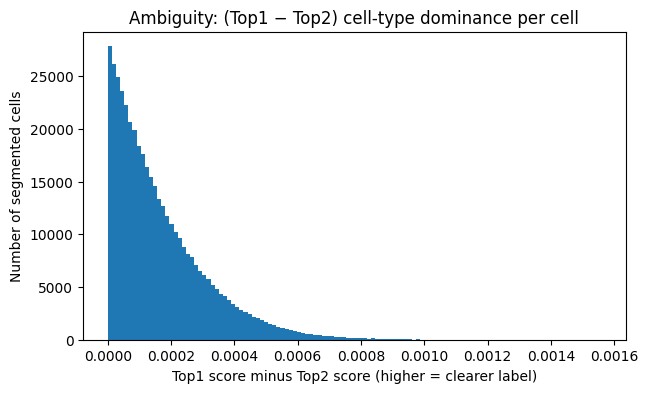

In [14]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(adata_vis.obs["c2l_margin_mean"], bins=120)
ax.set_title("Ambiguity: (Top1 − Top2) cell-type dominance per cell")
ax.set_xlabel("Top1 score minus Top2 score (higher = clearer label)")
ax.set_ylabel("Number of segmented cells")
plt.show()


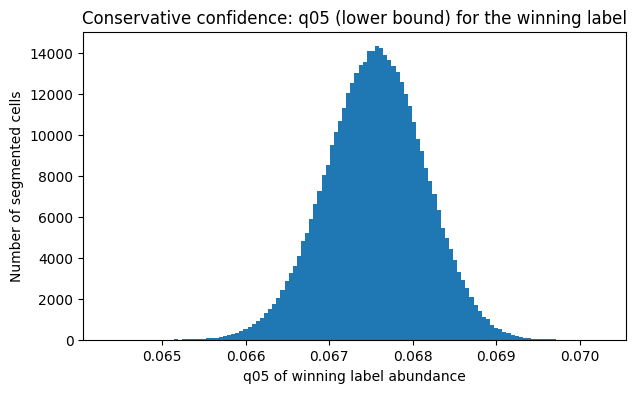

In [15]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(adata_vis.obs["c2l_q05_winner"], bins=120)
ax.set_title("Conservative confidence: q05 (lower bound) for the winning label")
ax.set_xlabel("q05 of winning label abundance")
ax.set_ylabel("Number of segmented cells")
plt.show()


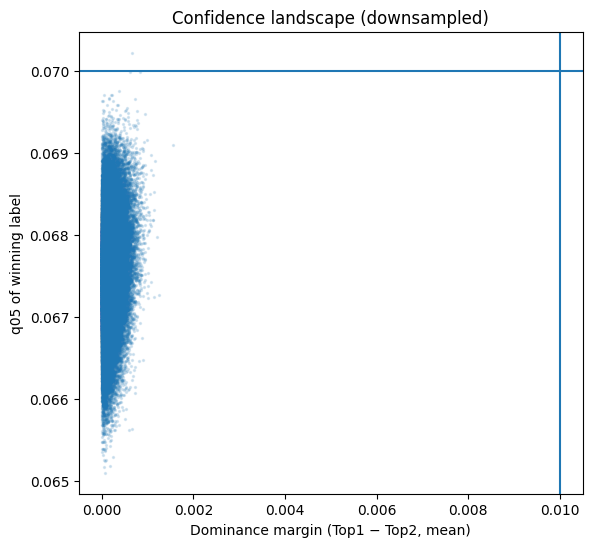

In [17]:
# downsample for scatter
n = adata_vis.n_obs
rng = np.random.default_rng(0)
take = rng.choice(n, size=min(n, 80_000), replace=False)

x = adata_vis.obs["c2l_margin_mean"].to_numpy()[take]
y = adata_vis.obs["c2l_q05_winner"].to_numpy()[take]

# choose example strict cutoffs (tune these)
# m_cut = 0.06
m_cut = 0.01
q_cut = 0.07
# q_cut = 0.10

fig, ax = plt.subplots(figsize=(6.5,6))
ax.scatter(x, y, s=2, alpha=0.15)
ax.axvline(m_cut)
ax.axhline(q_cut)
ax.set_title("Confidence landscape (downsampled)")
ax.set_xlabel("Dominance margin (Top1 − Top2, mean)")
ax.set_ylabel("q05 of winning label")
plt.show()


In [ ]:
m_cut = 0.06
q_cut = 0.10

conf = (adata_vis.obs["c2l_margin_mean"] >= m_cut) & (adata_vis.obs["c2l_q05_winner"] >= q_cut)

adata_vis.obs["c2l_label_strict"] = "Unassigned"
adata_vis.obs.loc[conf, "c2l_label_strict"] = adata_vis.obs.loc[conf, "c2l_label_mean"]

print("Fraction assigned:", conf.mean())
adata_vis.obs["c2l_label_strict"].value_counts().head(20)


Fraction assigned: 0.11745487905339624


c2l_label_strict
Unassigned     377108
Fibroblast      44441
Erythrocyte      2679
Endothelial      1216
Macrophage       1164
NK_cell           515
Neutrophils       116
CAR_T_cell         49
Monocyte            7
T_cell              1
Name: count, dtype: int64

# What's going on with the T cells

In [ ]:
w = clean_cols(adata_vis.obsm["means_cell_abundance_w_sf"])
w.idxmax(axis=1).value_counts().head(20)

Fibroblast     219966
Erythrocyte     72007
Neutrophils     42202
CAR_T_cell      22507
Macrophage      20436
Endothelial     12547
Monocyte        12356
NK_cell          9544
B_cell           5853
B/T_cell         4022
T_cell           3975
DC               1881
Name: count, dtype: int64

In [ ]:
w = clean_cols(adata_vis.obsm["means_cell_abundance_w_sf"])
w05 = clean_cols(adata_vis.obsm["q05_cell_abundance_w_sf"])

winner = w.idxmax(axis=1)
arr = w.to_numpy()
vals = np.sort(arr, axis=1)
margin = vals[:, -1] - vals[:, -2]

# q05 for winner
idx = pd.Index(w05.columns).get_indexer(winner.to_numpy())
rows = np.arange(adata_vis.n_obs)
q05_winner = w05.to_numpy()[rows, idx]

mask_bt = (winner == "B/T_cell").to_numpy()

print("B/T_cell winner count:", mask_bt.sum())
print("Margin stats for B/T_cell winners:")
print(pd.Series(margin[mask_bt]).describe(percentiles=[.5,.75,.9,.95,.99]))
print("q05_winner stats for B/T_cell winners:")
print(pd.Series(q05_winner[mask_bt]).describe(percentiles=[.5,.75,.9,.95,.99]))

# fraction that would pass your strict cutoffs
m_cut = 0.06
q_cut = 0.10
print("Fraction of B/T_cell winners passing strict:",
      ((margin[mask_bt] >= m_cut) & (q05_winner[mask_bt] >= q_cut)).mean())


B/T_cell winner count: 4022
Margin stats for B/T_cell winners:
count    4.022000e+03
mean     1.854689e-03
std      1.885380e-03
min      8.195639e-08
50%      1.198351e-03
75%      2.685346e-03
90%      4.451351e-03
95%      5.817620e-03
99%      8.384061e-03
max      1.359187e-02
dtype: float64
q05_winner stats for B/T_cell winners:
count    4022.000000
mean        0.159218
std         0.051275
min         0.057057
50%         0.183114
75%         0.192785
90%         0.199507
95%         0.203132
99%         0.208940
max         0.215414
dtype: float64
Fraction of B/T_cell winners passing strict: 0.0


In [ ]:
cols = np.array(w.columns)
top2 = np.argpartition(arr, kth=-2, axis=1)[:, -2:]
top2_labels = cols[top2]

# for B/T_cell winners, find the runner-up label
# identify which of the two is the winner vs runner-up
bt_top2 = top2_labels[mask_bt]
bt_vals_top2 = arr[mask_bt][:, top2[mask_bt] ]  # careful indexing might be messy; simpler approach:

# simpler: just take second best label from full sort
second_idx = np.argsort(arr[mask_bt], axis=1)[:, -2]
runner_up = cols[second_idx]
print(pd.Series(runner_up).value_counts().head(10))


Erythrocyte    700
B_cell         663
T_cell         500
Neutrophils    470
CAR_T_cell     450
NK_cell        440
DC             240
Fibroblast     179
Monocyte       157
Endothelial    150
Name: count, dtype: int64
